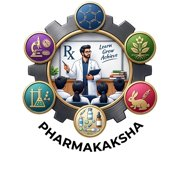

# BP604T · Unit I — AI in Natural Products and Pharmacognostic Data
**Pharmakaksha · Learn · Grow · Achieve**
*AI applications in Pharmaceutical Sciences · B.Pharm Semester VI · PCI NEP 2020*

This notebook contains every example and demo from the Unit I study notes, slides and video, in the same order.

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ajreddys/learn-pharmakaksha-site/blob/main/content/BP604T%20AI%20applications%20in%20Pharmaceutical%20Sciences%20%28Theory%29/BP604T_Unit1_AI_in_Natural_Products.ipynb)

**How to use this notebook**
1. Open it at [learn.pharmakaksha.com](https://learn.pharmakaksha.com/notebooks/index.html?path=BP604T%20AI%20applications%20in%20Pharmaceutical%20Sciences%20%28Theory%29/BP604T_Unit1_AI_in_Natural_Products.ipynb) (no login needed) or in **Google Colab** with the button above (sign in with Google; use **File → Save a copy in Drive** to keep your work).
2. Click a code cell and press **Shift + Enter** to run it. Run the cells from top to bottom.
3. The practice datasets sit next to this notebook. In Colab they are read from GitHub automatically.

**Using learn.pharmakaksha.com**
Python runs inside your web browser, so nothing is installed and nothing is sent to a server. Use an up-to-date Chrome, Edge, Firefox or Safari, on a laptop or a phone.
- **The first run is slow.** The first time you run a cell, the browser downloads Python, which can take 10–30 seconds. The first `import sklearn` takes a few seconds more. After that, cells run quickly.
- **Check the kernel.** *Python (Pyodide)* appears at the top right. A filled circle means Python is busy, and an empty circle means it is ready.
- **If a cell hangs** or you want a fresh start, use **Kernel → Restart Kernel**, then run the cells from the top again.
- **Save your work.** Press **Ctrl + S** (**Cmd + S** on a Mac). Your work is saved in this browser only. It will not appear on another device, and clearing your browsing data or using a private/incognito window erases it. Use **File → Download** to keep a copy.
- **Start over.** The site keeps opening your saved copy of the notebook. To get the original version back, go to the file list, tick the notebook, click **Delete** and reload the page.

> All datasets are fictional teaching data. Real drug names and structures are used only to show how the methods work. The models are for learning AI methods only. They are not quality-control, regulatory or clinical tools.

## 1.1 Representing crude-drug data
A crude drug is described by four kinds of data. A computer can only learn from numbers, so each kind must be **encoded**.

| Kind of data | Example (turmeric rhizome) | Type | How we encode it |
|---|---|---|---|
| Morphological | colour, fracture, odour | categorical | one-hot (0/1 columns) |
| Microscopic | starch grains per field, oil cells | counts / presence | numbers, 0/1 |
| Phytochemical | total ash %, curcumin % | continuous | numbers with units |
| Chromatographic | HPTLC band Rf, peak area | continuous / fingerprint | one number per band or peak |

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

URL = "https://raw.githubusercontent.com/ajreddys/learn-pharmakaksha-site/main/content/BP604T%20AI%20applications%20in%20Pharmaceutical%20Sciences%20%28Theory%29/"

def load(name):
    """Read a practice CSV from this folder, or from GitHub (Colab)."""
    if os.path.exists(name):
        return pd.read_csv(name)
    return pd.read_csv(URL + name)

In [ ]:
# Four crude-drug samples described with mixed data types
samples = pd.DataFrame({
    "colour":          ["orange-yellow", "orange-yellow", "pale yellow", "brownish"],   # morphological
    "fracture":        ["horny", "horny", "starchy", "horny"],                          # morphological
    "starch_grains":   [20, 24, 61, 12],                                                # microscopic (per field)
    "total_ash_pct":   [6.5, 7.1, 4.2, 13.9],                                           # phytochemical
    "curcumin_pct":    [3.9, 3.4, 1.8, 2.0],                                            # phytochemical (HPLC)
    "band_rf_0_42":    [1, 1, 1, 1],                                                    # chromatographic: curcumin band seen?
})
encoded = pd.get_dummies(samples, columns=["colour", "fracture"], dtype=int)
print(encoded.columns.tolist())
encoded

## 1.2 Structuring herbal datasets
Good herbal datasets follow simple rules: **one row per sample**, **one column per measurement**, units in the column name, and metadata such as source, plant part and season. The practice file `turmeric_samples.csv` holds 240 fictional turmeric powder samples tested in a QC lab.

In [ ]:
tur = load("turmeric_samples.csv")
print(tur.shape)
tur.head()

In [ ]:
tur.info()

In [ ]:
print(tur["label"].value_counts())
print()
print(tur["adulterant"].value_counts())

In [ ]:
# Average profile of each group: which tests look different?
tur.groupby("adulterant")[["total_ash_pct", "acid_insol_ash_pct", "curcumin_pct",
                           "volatile_oil_pct", "starch_grains_per_field"]].mean().round(2)

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))
colours = {"none": "#17725C", "starch": "#E07A2E", "zedoaria": "#7A5195",
           "metanil_yellow": "#D4A017", "brick_powder": "#8C2D19"}
for a, g in tur.groupby("adulterant"):
    ax.scatter(g["curcumin_pct"], g["total_ash_pct"], s=28, alpha=0.8, color=colours[a], label=a)
ax.set_xlabel("Curcumin (%)"); ax.set_ylabel("Total ash (%)")
ax.set_title("Turmeric samples: authentic vs adulterated")
ax.legend(title="Adulterant"); ax.grid(alpha=0.3); plt.show()

## 1.3 Authentic vs adulterated: a classification model
**Features (X):** the seven lab results. **Label (y):** 1 = adulterated, 0 = authentic. We keep 25% of the samples aside as a test set.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import accuracy_score, confusion_matrix, recall_score

features = ["moisture_pct", "total_ash_pct", "acid_insol_ash_pct", "curcumin_pct",
            "volatile_oil_pct", "starch_grains_per_field", "colour_L"]
X = tur[features]
y = (tur["label"] == "adulterated").astype(int)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)
print("Train:", len(X_train), " Test:", len(X_test), " Adulterated in test:", y_test.sum())

In [ ]:
# Baseline: a single pharmacopoeia-style rule on curcumin
rule = (X_test["curcumin_pct"] < 2.5).astype(int)
print("Rule 'curcumin < 2.5%'  accuracy:", round(accuracy_score(y_test, rule), 3),
      " adulterated caught:", round(recall_score(y_test, rule), 3))

logit = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000)).fit(X_train, y_train)
forest = RandomForestClassifier(n_estimators=300, random_state=42).fit(X_train, y_train)
for name, m in [("Logistic regression", logit), ("Random forest", forest)]:
    p = m.predict(X_test)
    print(f"{name:20s} accuracy: {accuracy_score(y_test, p):.3f}  adulterated caught: {recall_score(y_test, p):.3f}")

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
pred = logit.predict(X_test)          # the better model on this test set
print(confusion_matrix(y_test, pred))
ConfusionMatrixDisplay(confusion_matrix(y_test, pred), display_labels=["Authentic", "Adulterated"]).plot(cmap="Greens", colorbar=False)
plt.title("Logistic regression on the test samples"); plt.show()

In [ ]:
# Which adulterants does each approach catch?
test = tur.loc[X_test.index].copy()
test["rule"] = rule.values
test["logistic"] = pred
test["forest"] = forest.predict(X_test)
test[test["label"] == "adulterated"].groupby("adulterant")[["rule", "logistic", "forest"]].mean().round(2)

In [ ]:
imp = pd.Series(forest.feature_importances_, index=features).sort_values()
imp.plot.barh(color="#17725C", figsize=(7, 4))
plt.xlabel("Importance"); plt.title("Which tests the forest relies on"); plt.grid(alpha=0.3, axis="x"); plt.show()
print(imp.sort_values(ascending=False).round(3))

## 1.4 Predicting secondary-metabolite yield
`ashwagandha_yield.csv` records 120 fictional cultivation plots of *Withania somnifera*: altitude, harvest age, rainfall, soil nitrogen and irrigation, with the **withanolide content (%)** of the dried roots. This is a **regression** problem.

In [ ]:
ash = load("ashwagandha_yield.csv")
print(ash.shape)
ash.describe().round(2)

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error

feats = ["altitude_m", "harvest_age_days", "rainfall_mm", "soil_n_kg_ha", "irrigated"]
ash["age_sq"] = (ash["harvest_age_days"] - 180) ** 2      # domain knowledge: yield rises, peaks, then falls
Xa_train, Xa_test, ya_train, ya_test = train_test_split(ash[feats + ["age_sq"]], ash["withanolide_pct"],
                                                        test_size=0.25, random_state=7)
lin = LinearRegression().fit(Xa_train[feats], ya_train)
quad = LinearRegression().fit(Xa_train, ya_train)
rf = RandomForestRegressor(n_estimators=400, min_samples_leaf=3, random_state=7).fit(Xa_train[feats], ya_train)
for name, m, cols in [("Linear regression", lin, feats), ("Linear + age² term", quad, feats + ["age_sq"]),
                      ("Random forest", rf, feats)]:
    p = m.predict(Xa_test[cols])
    print(f"{name:19s} R2 = {r2_score(ya_test, p):.2f}   MAE = {mean_absolute_error(ya_test, p):.3f} % withanolide")

In [ ]:
# How does harvest age change the predicted yield? (other factors held at typical values)
typical = ash[feats].median()
ages = np.arange(140, 221, 5)
grid = pd.DataFrame([typical] * len(ages)); grid["harvest_age_days"] = ages
grid["age_sq"] = (ages - 180) ** 2
plt.figure(figsize=(8, 4.5))
plt.scatter(ash["harvest_age_days"], ash["withanolide_pct"], color="#12303A", alpha=0.35, s=20, label="Plots")
plt.plot(ages, quad.predict(grid), color="#E07A2E", linewidth=2.5, label="Linear + age² term")
plt.plot(ages, rf.predict(grid[feats]), color="#7A5195", linewidth=1.8, label="Random forest")
plt.plot(ages, lin.predict(grid[feats]), color="#17725C", linestyle="--", linewidth=2, label="Linear regression")
plt.xlabel("Harvest age (days)"); plt.ylabel("Withanolides (%)")
plt.title("Predicted withanolide content vs harvest age"); plt.legend(); plt.grid(alpha=0.3); plt.show()
print("Best harvest age (age² model):", ages[np.argmax(quad.predict(grid))], "days")

In [ ]:
new_plot = pd.DataFrame({"altitude_m": [1100], "harvest_age_days": [185], "rainfall_mm": [650],
                         "soil_n_kg_ha": [120], "irrigated": [0]})
new_plot["age_sq"] = (new_plot["harvest_age_days"] - 180) ** 2
print("Predicted withanolides:", round(quad.predict(new_plot)[0], 3), "%")

## 1.5 Phytochemical screening
Qualitative tests (Dragendorff for alkaloids, Shinoda for flavonoids, ferric chloride for tannins, foam test for saponins…) give **positive/negative** results, stored as 1/0. Quantitative assays give numbers: total phenolic content (TPC, mg gallic-acid equivalent per g) and DPPH IC₅₀ (µg/mL). A **lower IC₅₀ means stronger antioxidant activity**.

In [ ]:
phy = load("phytochem_screening.csv")
tests = ["alkaloids", "flavonoids", "tannins", "saponins", "glycosides", "terpenoids", "steroids"]
print((phy[tests].mean() * 100).round(0).astype(int).astype(str) + "% of extracts positive")
phy.head()

In [ ]:
fig, ax = plt.subplots(figsize=(7, 6))
ax.imshow(phy[tests].values, cmap="Greens", aspect="auto")
ax.set_xticks(range(len(tests))); ax.set_xticklabels(tests, rotation=45, ha="right")
ax.set_yticks(range(0, 40, 4)); ax.set_yticklabels(phy["extract_id"][::4])
ax.set_title("Screening matrix: dark = positive test"); plt.tight_layout(); plt.show()

In [ ]:
# Does phenolic content predict antioxidant activity? Use logs because both are skewed.
Xp = np.log(phy[["total_phenolic_mg_gae_g", "total_flavonoid_mg_qe_g"]])
yp = np.log(phy["dpph_ic50_ug_ml"])
m_phy = LinearRegression().fit(Xp, yp)
print("Coefficients:", m_phy.coef_.round(2), " R2 =", round(m_phy.score(Xp, yp), 2))

plt.figure(figsize=(7, 4.5))
plt.scatter(phy["total_phenolic_mg_gae_g"], phy["dpph_ic50_ug_ml"], color="#17725C")
plt.xscale("log"); plt.yscale("log")
plt.xlabel("Total phenolic content (mg GAE/g, log scale)"); plt.ylabel("DPPH IC50 (µg/mL, log scale)")
plt.title("More phenolics → lower IC50 (stronger antioxidant)"); plt.grid(alpha=0.3, which="both"); plt.show()

In [ ]:
# Which screening results go with strong activity (IC50 below the median)?
phy["strong"] = (phy["dpph_ic50_ug_ml"] < phy["dpph_ic50_ug_ml"].median()).astype(int)
print(phy.groupby("strong")[tests].mean().T.round(2))

## 1.6 Herb–drug interaction prediction
Each row of `herb_drug_pairs.csv` is a herb–drug pair described by **mechanism features**:
- herb effect on CYP3A4 and on P-glycoprotein (−1 = induces, 0 = none, 1 = inhibits); whether the herb has an antiplatelet effect;
- whether the drug is a CYP3A4 or P-gp substrate, has a narrow therapeutic index (NTI), or is an anticoagulant.

The label says whether a clinically significant interaction was reported. A **decision tree** learns readable rules.

In [ ]:
hdi = load("herb_drug_pairs.csv")
cols = ["herb_cyp3a4", "herb_pgp", "herb_antiplatelet", "drug_cyp3a4_substrate",
        "drug_pgp_substrate", "drug_narrow_ti", "drug_anticoagulant"]
# Combine herb and drug: does a CYP3A4 / P-gp effect meet a substrate?
hdi["cyp3a4_clash"] = ((hdi["herb_cyp3a4"] != 0) & (hdi["drug_cyp3a4_substrate"] == 1)).astype(int)
hdi["pgp_clash"] = ((hdi["herb_pgp"] != 0) & (hdi["drug_pgp_substrate"] == 1)).astype(int)
hdi["bleeding_clash"] = hdi["herb_antiplatelet"] * hdi["drug_anticoagulant"]
X_h = hdi[cols + ["cyp3a4_clash", "pgp_clash", "bleeding_clash"]]
y_h = hdi["significant_interaction"]
print(len(hdi), "pairs;", y_h.sum(), "with a significant interaction")

In [ ]:
from sklearn.tree import DecisionTreeClassifier, export_text
Xh_train, Xh_test, yh_train, yh_test = train_test_split(X_h, y_h, test_size=0.25, random_state=3, stratify=y_h)
tree = DecisionTreeClassifier(max_depth=3, random_state=0).fit(Xh_train, yh_train)
ph = tree.predict(Xh_test)
print("Accuracy:", round(accuracy_score(yh_test, ph), 3), " Interactions caught:", round(recall_score(yh_test, ph), 3))
print(export_text(tree, feature_names=list(X_h.columns)))

In [ ]:
# Missing a real interaction is worse than a false alarm, so lower the decision threshold
prob_h = tree.predict_proba(Xh_test)[:, 1]
for t in [0.5, 0.3]:
    p_t = (prob_h >= t).astype(int)
    print(f"Threshold {t}: interactions caught = {recall_score(yh_test, p_t):.2f},  pairs flagged = {p_t.sum()} of {len(p_t)}")

In [ ]:
# Use the tree on three pairs described by their known mechanisms
pairs = pd.DataFrame([
    # St John's wort induces CYP3A4 and P-gp; cyclosporine is a CYP3A4 + P-gp substrate with a narrow therapeutic index
    dict(herb_cyp3a4=-1, herb_pgp=-1, herb_antiplatelet=0, drug_cyp3a4_substrate=1, drug_pgp_substrate=1, drug_narrow_ti=1, drug_anticoagulant=0),
    # Ginkgo has an antiplatelet effect; warfarin is an anticoagulant with a narrow therapeutic index
    dict(herb_cyp3a4=0, herb_pgp=0, herb_antiplatelet=1, drug_cyp3a4_substrate=0, drug_pgp_substrate=0, drug_narrow_ti=1, drug_anticoagulant=1),
    # A herb with no CYP, P-gp or antiplatelet effect, with metformin
    dict(herb_cyp3a4=0, herb_pgp=0, herb_antiplatelet=0, drug_cyp3a4_substrate=0, drug_pgp_substrate=0, drug_narrow_ti=0, drug_anticoagulant=0),
], index=["St John's wort + cyclosporine", "Ginkgo + warfarin", "Neutral herb + metformin"])
pairs["cyp3a4_clash"] = ((pairs["herb_cyp3a4"] != 0) & (pairs["drug_cyp3a4_substrate"] == 1)).astype(int)
pairs["pgp_clash"] = ((pairs["herb_pgp"] != 0) & (pairs["drug_pgp_substrate"] == 1)).astype(int)
pairs["bleeding_clash"] = pairs["herb_antiplatelet"] * pairs["drug_anticoagulant"]
print(pd.Series(tree.predict_proba(pairs[X_h.columns])[:, 1].round(2), index=pairs.index, name="P(interaction)"))

## 1.7 Limitations
- **Small datasets.** Herbal studies often have tens of samples, so models overfit easily.
- **Natural variability.** Geography, season, harvest time and storage change the chemistry. A model trained on one region may fail on another.
- **Reference quality.** Labels are only as good as the authenticated reference samples (voucher specimens).
- **New adulterants.** A classifier only recognises the kinds of adulteration it was trained on.
- **Correlation is not mechanism.** Interaction predictions must be confirmed with pharmacological evidence.

## Worked example: screening a new consignment
Five new turmeric samples arrive. We use the logistic regression model to flag suspicious samples for confirmatory HPLC testing.

In [ ]:
consignment = pd.DataFrame({
    "moisture_pct":            [8.7, 9.4, 9.9, 8.5, 9.0],
    "total_ash_pct":           [6.9, 7.3, 4.1, 12.6, 6.4],
    "acid_insol_ash_pct":      [0.7, 0.9, 0.5, 4.2, 0.8],
    "curcumin_pct":            [3.8, 2.6, 1.9, 2.1, 3.3],
    "volatile_oil_pct":        [3.9, 3.1, 2.6, 2.4, 4.1],
    "starch_grains_per_field": [21, 30, 55, 14, 19],
    "colour_L":                [61.5, 66.0, 66.8, 56.0, 62.4],
}, index=["S1", "S2", "S3", "S4", "S5"])
prob = logit.predict_proba(consignment)[:, 1]
consignment["P(adulterated)"] = prob.round(2)
consignment["decision"] = np.where(prob >= 0.5, "Hold: confirm by HPLC", "Accept")
consignment[["curcumin_pct", "total_ash_pct", "starch_grains_per_field", "P(adulterated)", "decision"]]

## Quick check
A classifier trained only on starch-adulterated turmeric is shown a sample mixed with brick powder. Can you trust its answer? Decide, then run the cell.

In [ ]:
print("No. The model never saw brick powder. New kinds of adulteration need new training data (or a separate check such as acid-insoluble ash).")

## Try it yourself (lab)
Write your code in the empty cells. Solutions are at the end of the notebook.

**1.** Load `turmeric_samples.csv`. What percentage of samples are adulterated, and which adulterant is most common?

**2.** Train a logistic regression using only `curcumin_pct` and `total_ash_pct`. What is its test accuracy (same split as section 1.3)?

**3.** Using the ashwagandha data, fit a linear regression on `altitude_m` alone. By how much does the predicted withanolide content change for every 100 m of altitude?

**4.** In the phytochemical data, compute the correlation between `total_phenolic_mg_gae_g` and `dpph_ic50_ug_ml`. Is it positive or negative, and why?

---
## Solutions

In [ ]:
# 1
tur = load("turmeric_samples.csv")
print(round(100 * (tur["label"] == "adulterated").mean(), 1), "% adulterated")
print(tur.loc[tur["adulterant"] != "none", "adulterant"].value_counts().idxmax(), "is the most common adulterant")

In [ ]:
# 2
two = ["curcumin_pct", "total_ash_pct"]
m2 = make_pipeline(StandardScaler(), LogisticRegression()).fit(X_train[two], y_train)
print("Test accuracy:", round(m2.score(X_test[two], y_test), 3))

In [ ]:
# 3
m3 = LinearRegression().fit(ash[["altitude_m"]], ash["withanolide_pct"])
print(round(100 * m3.coef_[0], 3), "% withanolide per 100 m")

In [ ]:
# 4
r = phy["total_phenolic_mg_gae_g"].corr(phy["dpph_ic50_ug_ml"])
print("r =", round(r, 2), "→ negative: more phenolics means a lower IC50, i.e. stronger antioxidant activity")

---
**Next:** Unit II — AI in Medicinal and Pharmaceutical Chemistry. Pharmakaksha · Learn · Grow · Achieve